# 02 — Matplotlib Architecture
**Goal:** Understand the three-layer model (Figure → Axes → Artist) so you can
do *anything* matplotlib supports, not just the examples in tutorials.

In [1]:
import os
os.chdir('/Volumes/SSD_Gabo/proyectos/growth-analytics')

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.figure import Figure
from matplotlib.axes import Axes
from matplotlib.lines import Line2D

print('matplotlib', plt.matplotlib.__version__)

matplotlib 3.11.0


## 1. The three layers

Matplotlib is organized in three concentric layers:

```
Backend layer    PNG, SVG, PDF, screen — invisible to most users
  ▲
  │
Artist layer     Everything you can see: Figure, Axes, Line2D, Text, Patch
  ▲
  │
Scripting layer  pyplot (state-machine) — what plt.subplots() uses
```

When you call `fig, ax = plt.subplots()`, you build a `Figure` (canvas) and an
`Axes` (plot area). Every drawable thing — line, tick, legend, axis label — is
an `Artist` that lives inside the Axes.

In [2]:
fig, ax = plt.subplots()
ax.plot([1, 2, 3], [1, 4, 9])

print('fig     :', type(fig).__name__, '→ canvas')
print('ax      :', type(ax).__name__,  '→ one plot inside the canvas')
line = ax.lines[0]
print('line    :', type(line).__name__)
print('  xdata :', line.get_xdata())
print('  ydata :', line.get_ydata())
plt.close(fig)

fig     : Figure → canvas
ax      : Axes → one plot inside the canvas
line    : Line2D
  xdata : [1 2 3]
  ydata : [1 4 9]


## 2. The two APIs — pyplot vs OO

Matplotlib offers two styles. **Always use the OO style in real code.**

| Aspect | pyplot (`plt.title`) | OO (`ax.set_title`) |
|---|---|---|
| Where it acts | Current `Axes` | The `Axes` you pass |
| Works with subplots | Risky | Always safe |
| Reusable as a function | No (relies on global state) | Yes |
| Discoverable in IDE | No | Yes |
| Recommended | Throwaway scripts only | Production code |

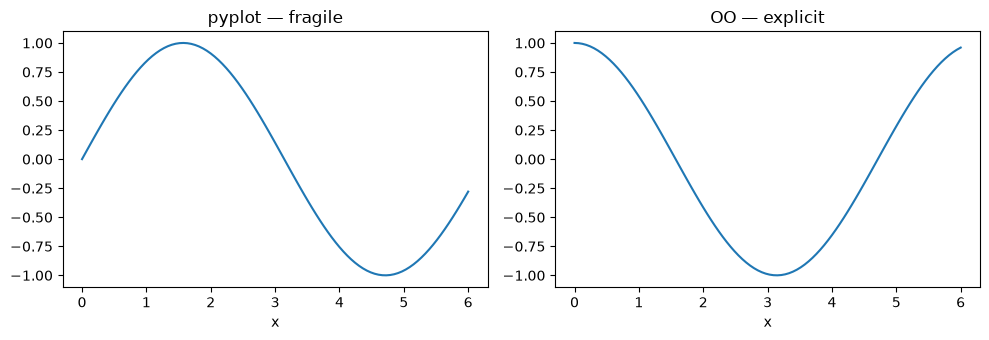

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
x = np.linspace(0, 6, 100)

plt.sca(axes[0])
plt.plot(x, np.sin(x))
plt.title('pyplot — fragile')
plt.xlabel('x')

axes[1].plot(x, np.cos(x))
axes[1].set_title('OO — explicit')
axes[1].set_xlabel('x')

plt.tight_layout()
plt.show()

## 3. Building a reusable chart function

The OO style unlocks a key habit: **write chart functions that take an Axes**.
This is how seaborn, plotly, and pro plotting libraries are built under the
hood.

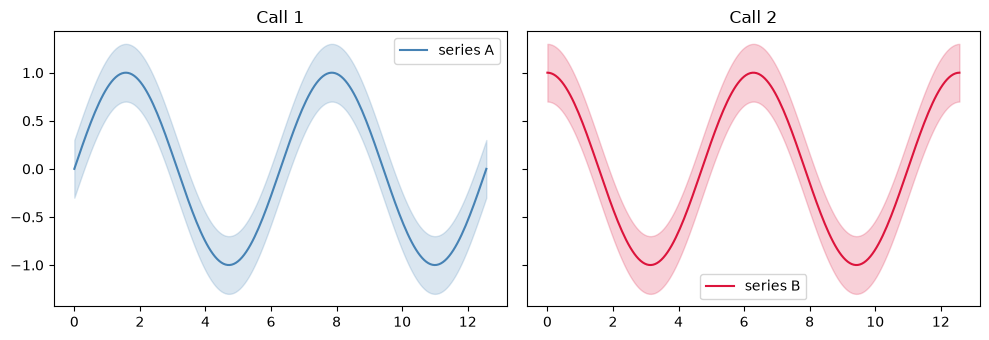

In [4]:
def line_with_band(ax, x, y, y_low, y_high, **kwargs):
    line, = ax.plot(x, y, **kwargs)
    color  = line.get_color()
    ax.fill_between(x, y_low, y_high, color=color, alpha=0.2)
    return line

x = np.linspace(0, 4*np.pi, 200)
y = np.sin(x)
y_low, y_high = y - 0.3, y + 0.3

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), sharey=True)
line_with_band(axes[0], x, y, y_low, y_high, color='steelblue', label='series A')
axes[0].legend(); axes[0].set_title('Call 1')

line_with_band(axes[1], x, np.cos(x), np.cos(x)-0.3, np.cos(x)+0.3,
               color='crimson', label='series B')
axes[1].legend(); axes[1].set_title('Call 2')
plt.tight_layout()
plt.show()

## 4. The two `subplots` patterns

**Pattern A — uniform grid:**
```python
fig, axes = plt.subplots(2, 3, figsize=(12, 6))
axes[0, 0].plot(...)
```
**Pattern B — irregular grid (use `gridspec` or `subplot_mosaic`):**
```python
fig = plt.figure(figsize=(12, 6))
ax1 = fig.add_subplot(2, 2, 1)   # top-left
ax2 = fig.add_subplot(2, 2, 2)   # top-right
ax3 = fig.add_subplot(2, 1, 2)   # bottom, full width
```
Pattern A is what you'll use 90% of the time. Notebook 09 goes deep on layouts.

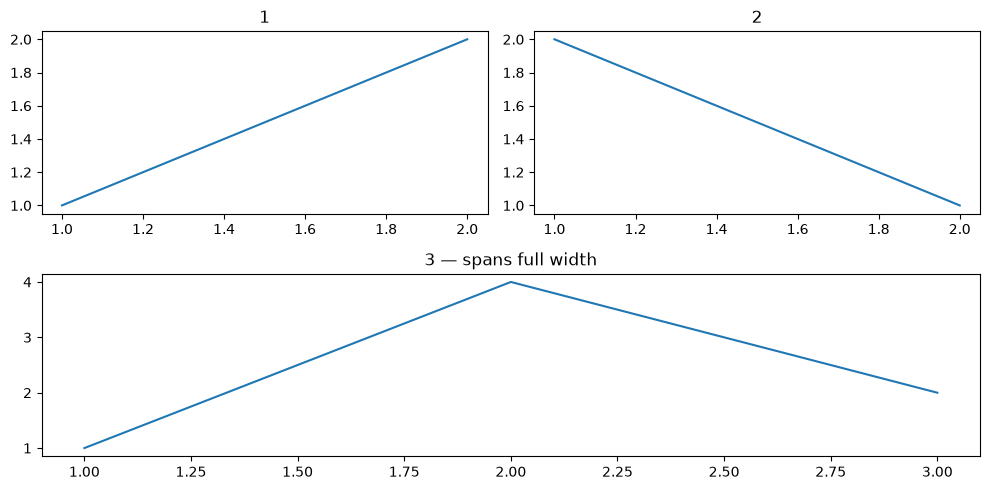

In [5]:
fig = plt.figure(figsize=(10, 5))
ax1 = fig.add_subplot(2, 2, 1); ax1.set_title('1'); ax1.plot([1, 2], [1, 2])
ax2 = fig.add_subplot(2, 2, 2); ax2.set_title('2'); ax2.plot([1, 2], [2, 1])
ax3 = fig.add_subplot(2, 1, 2); ax3.set_title('3 — spans full width'); ax3.plot([1, 2, 3], [1, 4, 2])
plt.tight_layout()
plt.show()

## 5. Artists in depth

Every drawable on a chart is an `Artist`. The Axes maintains collections of
them, and that's how legends, z-order, and `setp` work.

ax.lines    : <Axes.ArtistList of 1 lines>
ax.patches : <Axes.ArtistList of 0 patches>
ax.collections : <Axes.ArtistList of 1 collections>
zorder of the line  : 2
zorder of the point : 3


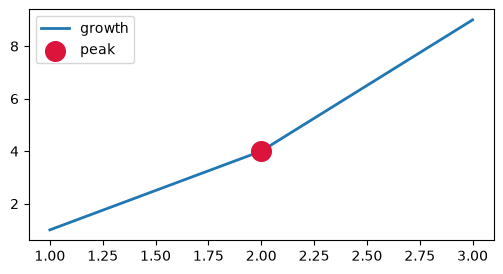

In [6]:
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot([1, 2, 3], [1, 4, 9], label='growth', linewidth=2)
ax.scatter([2], [4], s=200, color='crimson', zorder=3, label='peak')
ax.legend()

print('ax.lines    :', ax.lines)
print('ax.patches :', ax.patches)
print('ax.collections :', ax.collections)
print('zorder of the line  :', ax.lines[0].zorder)
print('zorder of the point :', ax.collections[0].zorder)
plt.show()

## 6. Performance — what to do with 1M points

Matplotlib becomes slow when you have **many artists**. Strategies:

1. **Downsample** before plotting.
2. Use `Line2D` with a single artist instead of many `scatter` calls.
3. Use `rasterized=True` for huge scatter layers in vector backends.
4. Switch to `plotly` or `datashader` for millions of points.

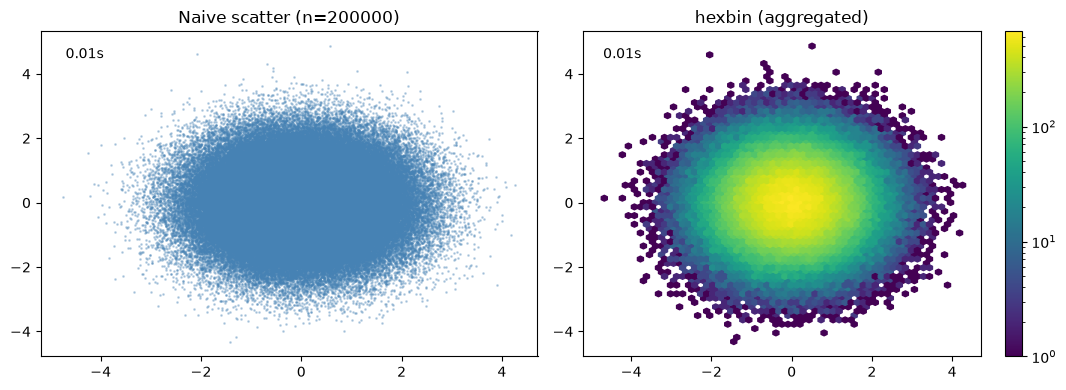

In [7]:
import time

n = 200_000
x = np.random.randn(n)
y = np.random.randn(n)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

t0 = time.perf_counter()
axes[0].scatter(x, y, s=1, alpha=0.3, color='steelblue')
axes[0].set_title(f'Naive scatter (n={n})')
t1 = time.perf_counter()
axes[0].text(0.05, 0.95, f'{t1-t0:.2f}s', transform=axes[0].transAxes, va='top')

from matplotlib.colors import LogNorm
t0 = time.perf_counter()
hb = axes[1].hexbin(x, y, gridsize=60, cmap='viridis', norm=LogNorm())
axes[1].set_title('hexbin (aggregated)')
t1 = time.perf_counter()
axes[1].text(0.05, 0.95, f'{t1-t0:.2f}s', transform=axes[1].transAxes, va='top')
fig.colorbar(hb, ax=axes[1])
plt.tight_layout()
plt.show()

## 7. The dual backends (Agg, Qt, notebook)

```
Backend  = the renderer (PNG/SVG/PDF/screen)
Frontend = how you call matplotlib (pyplot, OO, notebook magic)
```
Useful in Jupyter:
- `%matplotlib inline`     static PNG (default in classic notebook)
- `%matplotlib widget`     interactive zoom/pan (needs `ipympl`)
- `%matplotlib notebook`   interactive (deprecated in newer jupyterlab)
Outside Jupyter you usually set the backend via `plt.switch_backend('Agg')`
or in `~/.matplotlib/matplotlibrc`.

In [8]:
print('Current backend:', plt.get_backend())
print('Backend listing via matplotlib.rcsetup (all keys):')
bks = [k for k in plt.matplotlib.rcsetup.__dict__ if 'backend' in k.lower()]
print(bks)
print('\nTo set a backend:  plt.switch_backend("Agg")  or use the %matplotlib magic')

Current backend: module://matplotlib_inline.backend_inline
Backend listing via matplotlib.rcsetup (all keys):
['backend_registry', '_auto_backend_sentinel', 'validate_backend']

To set a backend:  plt.switch_backend("Agg")  or use the %matplotlib magic


## Summary

| Concept | Key point |
|---|---|
| Three layers | Backend → Artist → Scripting |
| Figure / Axes / Artist | Canvas, plot area, drawable thing |
| OO style | `ax.set_title(...)` — always prefer |
| Reusable functions | Take an `Axes` argument |
| Performance | Aggregate (hexbin, 2D hist) or downsample for big data |
| Backends | `inline`, `widget`, `Agg` for files |

**Next:** `03_chart_anatomy_and_styling.ipynb` — making charts look professional.